# 📌 Pretraining

In [1]:
import os
import sys

REPO_URL = 'https://github.com/lucasqueiros/hpc.git'

%cd /content

if os.path.exists('hpc'):
    !rm -rf hpc

!git clone {REPO_URL}
%cd hpc

UTILS_PATH = '/content/hpc/llm-lab/utils/matteus'

if UTILS_PATH not in sys.path:
    sys.path.append(UTILS_PATH)

/content
Cloning into 'hpc'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 180 (delta 64), reused 115 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 16.77 MiB | 19.23 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/hpc


- Generating text and calculating the cross-entropy loss

In [2]:
from utils_llm import generate_text_simple, GPT_CONFIG_124M, GPTModel
import torch

model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [3]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'[EOS]'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [4]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=5,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you correctlighting statutesago avoided


In [5]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [6]:
with torch.no_grad():
    logits = model(inputs)

print(logits.shape)

torch.Size([2, 3, 50257])


In [7]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

In [8]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(11.0566)

Compute training and validation cross-entropy loss for GPTModel on the Frankenstein dataset.

In [9]:
import requests
url = "https://www.gutenberg.org/files/84/84-0.txt"

def load_frankenstein():
    response = requests.get(url)
    response.raise_for_status()
    return response.text

text = load_frankenstein()

In [10]:
total_characters = len(text)
total_tokens = len(tokenizer.encode(text))

print(f"Characters: {total_characters}")
print(f"tokens: {total_tokens}")

Characters: 419434
tokens: 101747


In [11]:
from utils_llm import create_dataloader_v1

train_ratio = 0.90
split_index = int(train_ratio * len(text))
train_data = text[:split_index]
val_data = text[split_index:]

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [12]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 91136
Validation tokens: 9984
All tokens: 101120


In [13]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [14]:
device = torch.device("cuda")
model.to(device);

In [15]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 11.00749293873819
Validation loss: 11.009457063674926


In [16]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(63358.8008)


# 📌 GPT Model Training

In [17]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [18]:
generate_and_print_sample(model=model, tokenizer=tokenizer, device=device, start_context="the king of")

the king ofcci Quadro declined levelinglockedORPGcciamargodgraEduc genresATIONS vocal smashing Lad Sy Frieza eventually Blessed accepts TrapsbaughCommun knotRoger Schultz272 Unicgary Edit idle Naztons Il Roots retention tariffulnerabilityrimination Caldwell cellarENAhew Shawn KEYjp BeatsInternational implements


In [19]:
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
    start_context="the king of", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.689, Val loss 9.738
Ep 1 (Step 000050): Train loss 6.571, Val loss 6.764
Ep 1 (Step 000100): Train loss 6.238, Val loss 6.360
Ep 1 (Step 000150): Train loss 6.173, Val loss 6.193
the king of the the theI�I have, and the the the the�I have, and I was the the the�I was the the the the the�I have, and I was the
Ep 2 (Step 000200): Train loss 5.647, Val loss 6.132
Ep 2 (Step 000250): Train loss 5.503, Val loss 6.045
Ep 2 (Step 000300): Train loss 5.190, Val loss 5.998
Ep 2 (Step 000350): Train loss 5.076, Val loss 5.907
the king of the the cottagers, and the the the cottagers of the the the the the the the old man, and the same the the cottagers, and the the cott
Ep 3 (Step 000400): Train loss 4.982, Val loss 5.895
Ep 3 (Step 000450): Train loss 4.967, Val loss 5.872
Ep 3 (Step 000500): Train loss 4.780, Val loss 5.861
the king of the the cottagers, and the the cottagers, and I was the cottagers. I was a  the old man, and the the monster, and the monster, a

In [20]:
generate_and_print_sample(model=model, tokenizer=tokenizer, device=device, start_context="the king of")

the king of my employment. The dissecting room and Agatha were not consent to me and me thy compassion. By some papers of anguish that banished, and throwing myself on my promise of creating another like to deprecate the malign


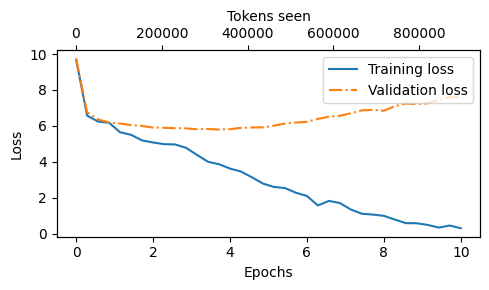

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Decoding strategies

In [22]:
inference_device = "cpu"
model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("the king of", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 the king of my employment. The
dissecting room and Agatha were not consent to me and
me thy compassion. By some


In [23]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [24]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("the king of", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 the king of ice, “Devil, loaded by this proceeding. ‘d
